#AlexNet Implementation


### Problem Statement
Implement the AlexNet architecture using PyTorch and train it on ImageNette - a 10-class subset of ImageNet. In this notebook, we build the architecture from scratch, train it, and evaluate its performance.

## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
import tarfile

## Check Device

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## Download ImageNette Dataset
ImageNette is a subset of 10 easily classifiable ImageNet classes created by fast.ai. It contains around 13K images at 320px resolution.

In [ ]:
url = 'https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz'
filename = 'imagenette2-320.tgz'
data_dir = 'imagenette2-320'

if not os.path.exists(data_dir):
    print('Downloading ImageNette...')
    urllib.request.urlretrieve(url, filename)
    print('Extracting...')
    with tarfile.open(filename, 'r:gz') as tar:
        tar.extractall('.')
    print('Done!')
else:
    print('Dataset already exists.')

## Define Data Transforms
AlexNet expects 227x227 input images. We apply data augmentation on training data (random resized crop, horizontal flip) and normalize using ImageNet statistics.

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(227),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(227),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Load Dataset

In [ ]:
train_dataset = ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset = ImageFolder(os.path.join(data_dir, 'val'), transform=val_transform)

In [ ]:
print('Training samples:', len(train_dataset))
print('Validation samples:', len(val_dataset))
print('Number of classes:', len(train_dataset.classes))

Training samples: 9469
Validation samples: 3925
Number of classes: 10


## Class Names
ImageNette uses WordNet synset IDs. Let's map them to readable names.

In [ ]:
class_names = {
    'n01440764': 'tench',
    'n02102040': 'English springer',
    'n02979186': 'cassette player',
    'n03000684': 'chain saw',
    'n03028079': 'church',
    'n03394916': 'French horn',
    'n03417042': 'garbage truck',
    'n03425413': 'gas pump',
    'n03445777': 'golf ball',
    'n03888257': 'parachute'
}

readable_classes = [class_names.get(c, c) for c in train_dataset.classes]
print('Classes:', readable_classes)

Classes: ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']


## Create DataLoaders

In [ ]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## Display Sample Images

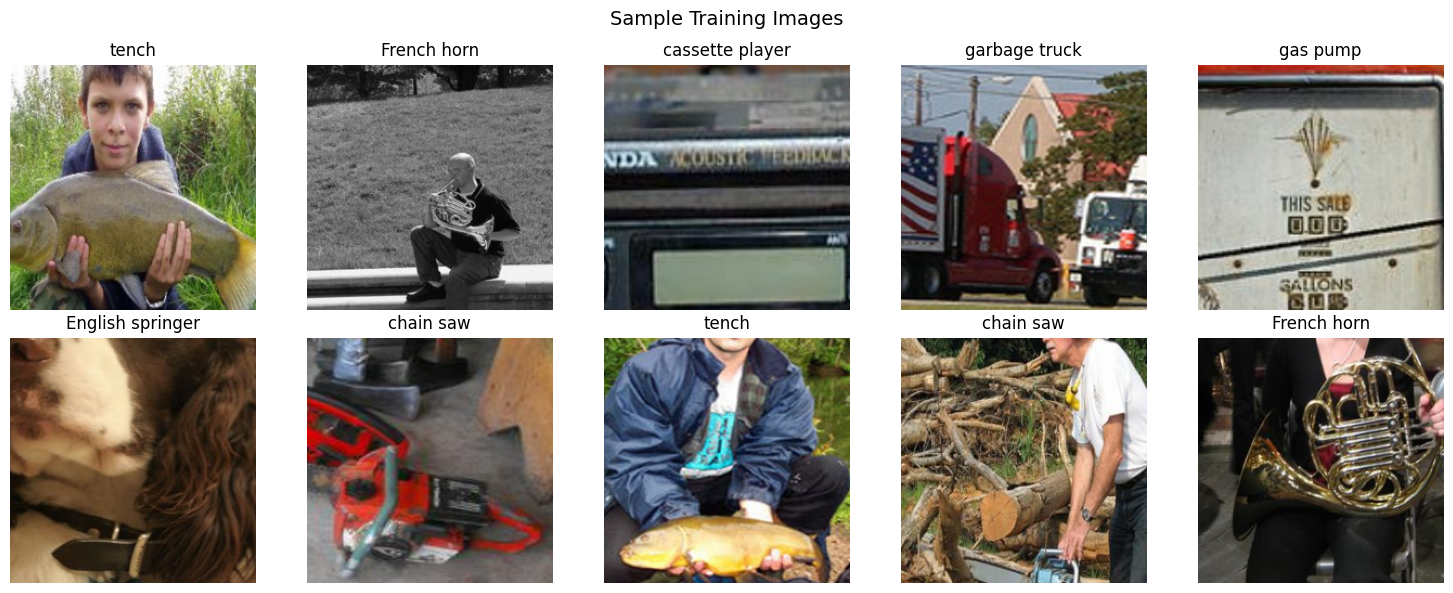

In [ ]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img * std + mean

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img)
    ax.set_title(readable_classes[labels[i]])
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## Check Input Shape

In [ ]:
print('Batch shape:', images.shape)
print('Single image shape:', images[0].shape)

Batch shape: torch.Size([64, 3, 227, 227])
Single image shape: torch.Size([3, 227, 227])


## Define AlexNet Architecture
AlexNet has 5 convolutional layers followed by 3 fully connected layers. Key features: ReLU activation, overlapping max pooling, dropout regularization, and Local Response Normalization (LRN).

### Feature Extractor (Convolutional Layers)

In [ ]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()

        # Feature extractor: 5 convolutional layers
        self.features = nn.Sequential(
            # Conv1: 227x227x3 -> 55x55x96
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),  # -> 27x27x96

            # Conv2: 27x27x96 -> 27x27x256
            nn.Conv2d(96,256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),  # -> 13x13x256

            # Conv3: 13x13x256 -> 13x13x384
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # Conv4: 13x13x384 -> 13x13x384
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            # Conv5: 13x13x384 -> 13x13x256
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),  # -> 6x6x256
        )

        # Classifier: 3 fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

## Instantiate Model
Model instantiation involves creating a concrete, executable object from a defined model class, initializing its parameters for computational use.

In [ ]:
model = AlexNet(num_classes=10).to(device)
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): L

## Parameter Count
The original AlexNet has ~62 million parameters. Our version has fewer since the final layer outputs 10 classes instead of 1000.

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters: 58,322,314
Trainable parameters: 58,322,314


## Layer-wise Parameter Breakdown

In [ ]:
import pandas as pd

layer_info = []
for name, param in model.named_parameters():
    layer_info.append({
        'Layer': name,
        'Shape': str(list(param.shape)),
        'Parameters': param.numel()
    })

df_params = pd.DataFrame(layer_info)
df_params

,Layer,Shape,Parameters
0,features.0.weight,"[96, 3, 11, 11]",34848
1,features.0.bias,[96],96
2,features.4.weight,"[256, 96, 5, 5]",614400
3,features.4.bias,[256],256
4,features.8.weight,"[384, 256, 3, 3]",884736
5,features.8.bias,[384],384
6,features.10.weight,"[384, 384, 3, 3]",1327104
7,features.10.bias,[384],384
8,features.12.weight,"[256, 384, 3, 3]",884736
9,features.12.bias,[256],256


## Verify Forward Pass
Pass a dummy input through the model to ensure shapes are correct.

In [ ]:
dummy = torch.randn(1, 3, 227, 227).to(device)
output = model(dummy)
print('Output shape:', output.shape)

Output shape: torch.Size([1, 10])


## Training Setup
The original AlexNet used SGD with momentum of 0.9 and weight decay of 0.0005.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

## Define Training Function

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

## Define Evaluation Function

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

## Train the Model
We train for 10 epochs. On a Colab GPU, each epoch takes about 1-2 minutes.

In [ ]:
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

Epoch [1/10] Train Loss: 2.3024 | Train Acc: 9.94% | Val Loss: 2.3021 | Val Acc: 9.10%
Epoch [2/10] Train Loss: 2.2759 | Train Acc: 14.35% | Val Loss: 2.2084 | Val Acc: 22.90%
Epoch [3/10] Train Loss: 2.1367 | Train Acc: 21.65% | Val Loss: 2.0621 | Val Acc: 24.28%
Epoch [4/10] Train Loss: 2.0737 | Train Acc: 24.23% | Val Loss: 1.9963 | Val Acc: 27.49%
Epoch [5/10] Train Loss: 2.0099 | Train Acc: 29.14% | Val Loss: 1.8678 | Val Acc: 33.43%
Epoch [6/10] Train Loss: 1.8676 | Train Acc: 35.61% | Val Loss: 1.7518 | Val Acc: 39.46%
Epoch [7/10] Train Loss: 1.8274 | Train Acc: 37.07% | Val Loss: 1.7422 | Val Acc: 39.49%
Epoch [8/10] Train Loss: 1.7949 | Train Acc: 37.66% | Val Loss: 1.6727 | Val Acc: 41.68%
Epoch [9/10] Train Loss: 1.7696 | Train Acc: 39.26% | Val Loss: 1.6690 | Val Acc: 42.04%
Epoch [10/10] Train Loss: 1.7317 | Train Acc: 40.31% | Val Loss: 1.5793 | Val Acc: 45.15%


## Training Curves

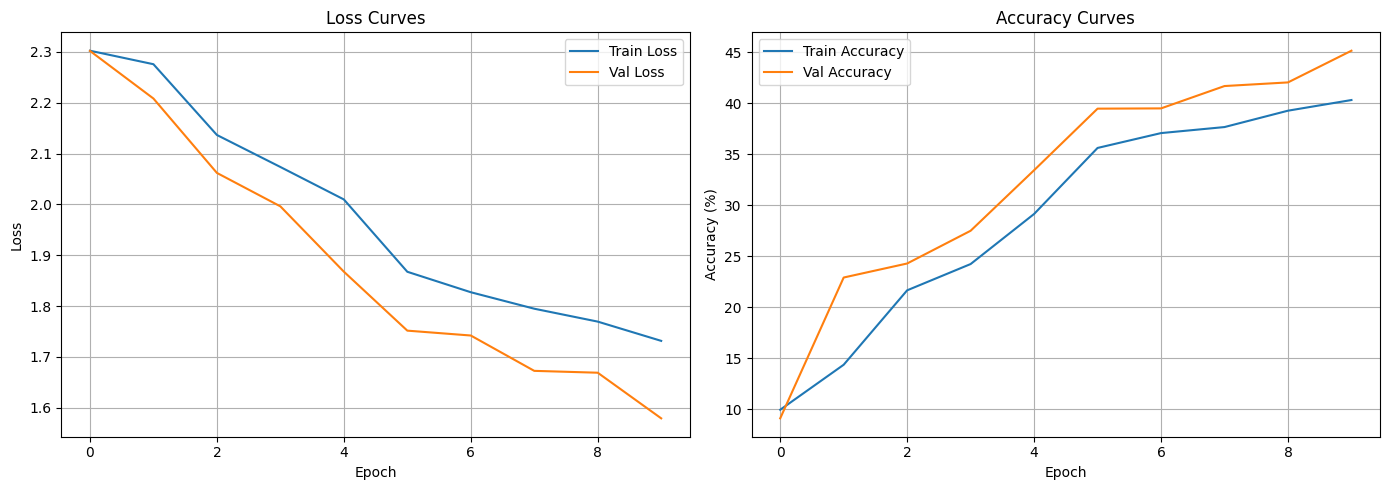

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True)

ax2.plot(history['train_acc'], label='Train Accuracy')
ax2.plot(history['val_acc'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


Training AlexNet from scratch on ImageNette yields modest accuracy (~43%) because the model has 58M parameters but only ~9.5K training images. This massive gap between model capacity and data size makes it hard to learn meaningful features from scratch. In the original paper, AlexNet was trained on 1.2M ImageNet images — over 100x more data. This demonstrates why transfer learning became the standard approach for smaller datasets.

## Per-Class Accuracy

In [ ]:
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        for i in range(labels.size(0)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

class_acc = pd.DataFrame({
    'Class': readable_classes,
    'Correct': class_correct,
    'Total': class_total,
    'Accuracy (%)': [100.0 * c / t if t > 0 else 0 for c, t in zip(class_correct, class_total)]
})
class_acc

,Class,Correct,Total,Accuracy (%)
0,tench,0,387,0.0
1,English springer,0,395,0.0
2,cassette player,0,357,0.0
3,chain saw,0,386,0.0
4,church,409,409,100.0
5,French horn,0,394,0.0
6,garbage truck,0,389,0.0
7,gas pump,0,419,0.0
8,golf ball,0,399,0.0
9,parachute,0,390,0.0


## Visualize Predictions

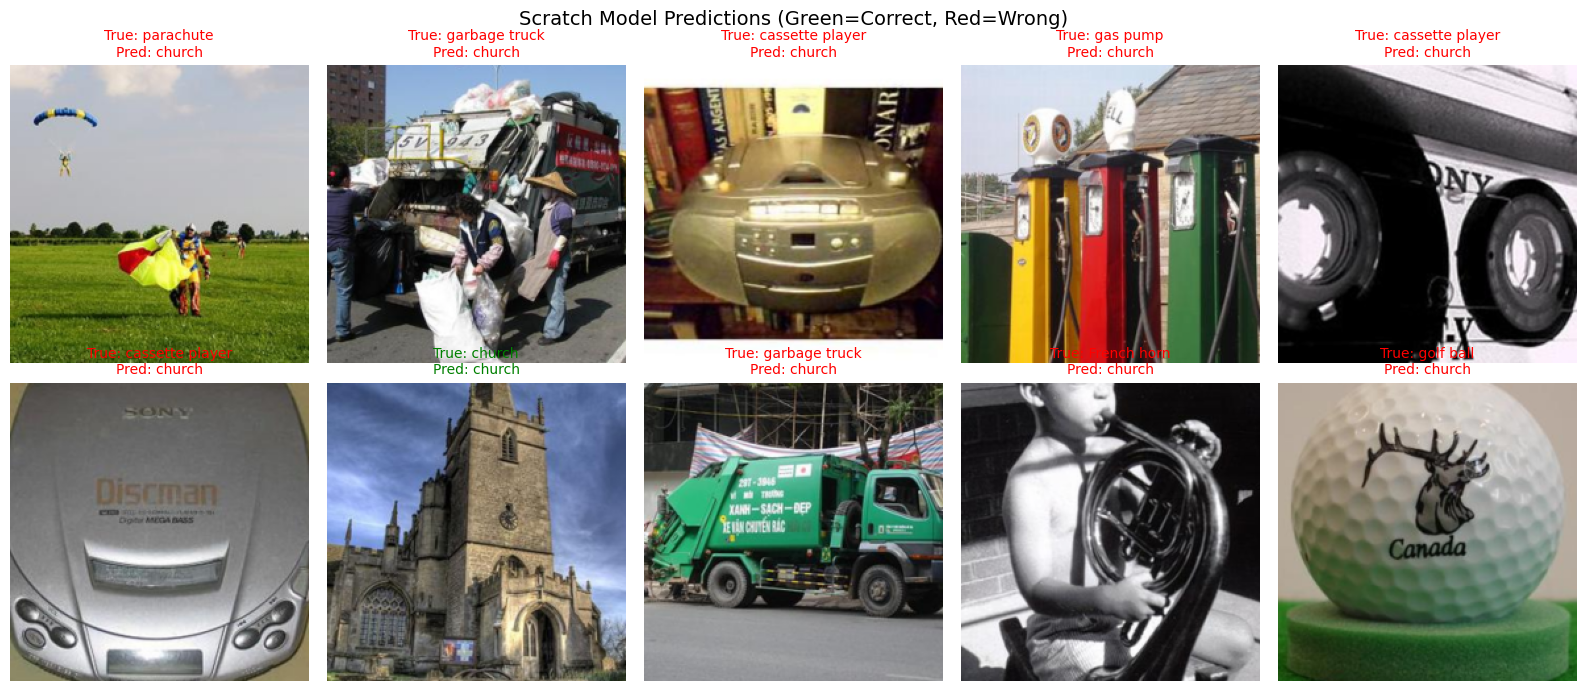

In [ ]:
model.eval()
torch.manual_seed(42)
sample_indices = torch.randperm(len(val_dataset))[:10]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    img, label = val_dataset[sample_indices[i]]
    img_dev = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_dev)
        _, pred = output.max(1)

    img_show = denormalize(img).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_show)
    true_label = readable_classes[label]
    pred_label = readable_classes[pred.cpu().item()]
    color = 'green' if label == pred.cpu().item() else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Scratch Model Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()


We implemented AlexNet from scratch in PyTorch and trained it on ImageNette, a 10-class subset of ImageNet. The architecture uses 5 convolutional layers and 3 fully connected layers with key innovations: ReLU activation, overlapping max pooling, dropout regularization, data augmentation, and Local Response Normalization. AlexNet's 2012 ILSVRC win marked the beginning of the deep learning era in computer vision.

## Pretrained AlexNet (Transfer Learning)
Let's compare by using an AlexNet pretrained on the full ImageNet dataset and fine-tuning it on ImageNette.

### Load pretrained model:

In [ ]:
pretrained_model = torchvision.models.alexnet(weights='IMAGENET1K_V1')

# Replace the final classifier layer for 10 classes
pretrained_model.classifier[6] = nn.Linear(4096, 10)
pretrained_model = pretrained_model.to(device)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 121MB/s]


In [ ]:
# Freeze convolutional layers, only train the classifier
for param in pretrained_model.features.parameters():
    param.requires_grad = False

In [ ]:
pt_criterion = nn.CrossEntropyLoss()
pt_optimizer = optim.SGD(pretrained_model.classifier.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

In [ ]:
num_epochs_pt = 5
pt_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs_pt):
    train_loss, train_acc = train_one_epoch(pretrained_model, train_loader, pt_criterion, pt_optimizer, device)
    val_loss, val_acc = evaluate(pretrained_model, val_loader, pt_criterion, device)

    pt_history['train_loss'].append(train_loss)
    pt_history['train_acc'].append(train_acc)
    pt_history['val_loss'].append(val_loss)
    pt_history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs_pt}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

Epoch [1/5] Train Loss: 0.5316 | Train Acc: 82.83% | Val Loss: 0.1830 | Val Acc: 94.04%
Epoch [2/5] Train Loss: 0.3296 | Train Acc: 89.63% | Val Loss: 0.1523 | Val Acc: 94.96%
Epoch [3/5] Train Loss: 0.3101 | Train Acc: 89.99% | Val Loss: 0.1486 | Val Acc: 94.93%
Epoch [4/5] Train Loss: 0.2751 | Train Acc: 91.17% | Val Loss: 0.1389 | Val Acc: 95.39%
Epoch [5/5] Train Loss: 0.2686 | Train Acc: 91.18% | Val Loss: 0.1307 | Val Acc: 95.62%


## Visualize Predictions (Pretrained Model)
Using the same sample images to directly compare with the scratch model.

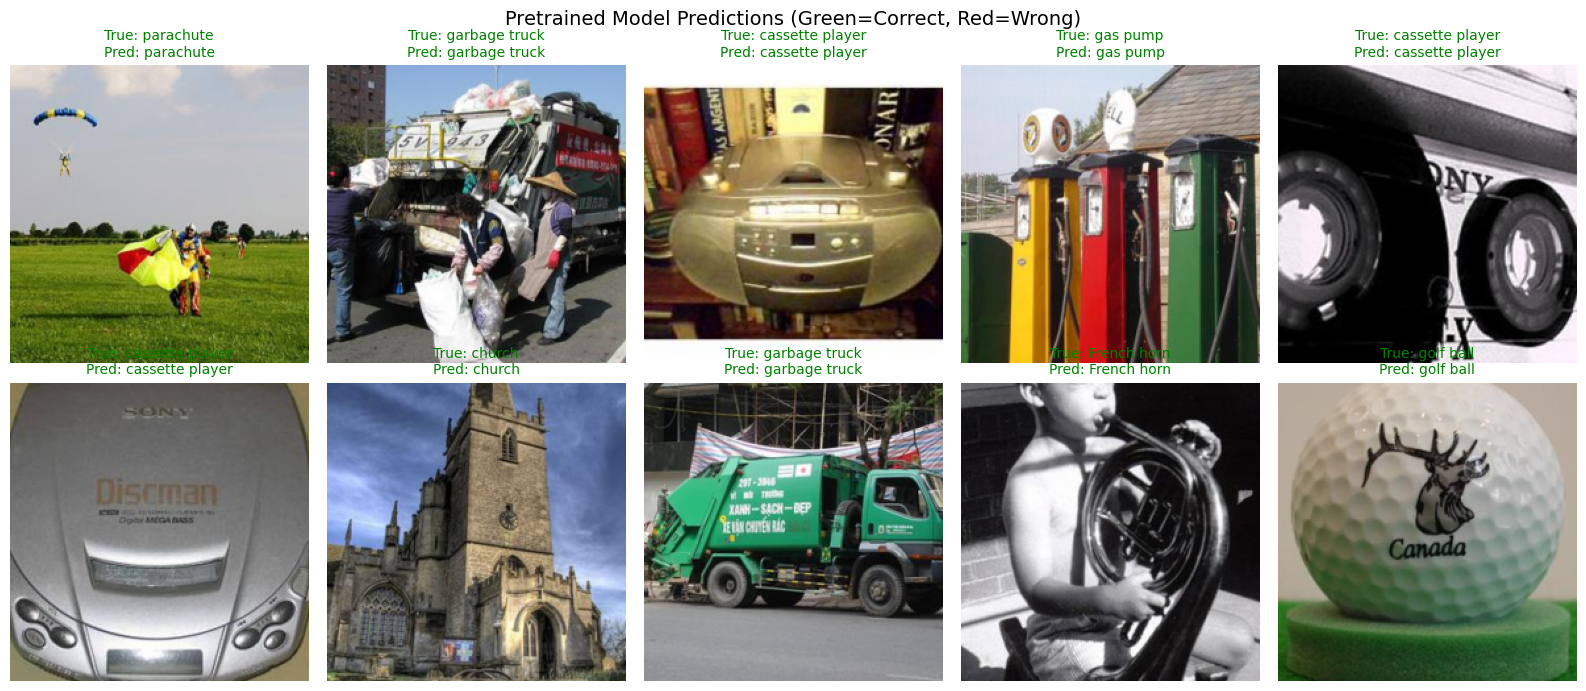

In [ ]:
pretrained_model.eval()

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    img, label = val_dataset[sample_indices[i]]
    img_dev = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = pretrained_model(img_dev)
        _, pred = output.max(1)

    img_show = denormalize(img).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_show)
    true_label = readable_classes[label]
    pred_label = readable_classes[pred.cpu().item()]
    color = 'green' if label == pred.cpu().item() else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Pretrained Model Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Approach': ['From Scratch (10 epochs)', 'Pretrained + Fine-tuned (5 epochs)'],
    'Train Accuracy (%)': [history['train_acc'][-1], pt_history['train_acc'][-1]],
    'Val Accuracy (%)': [history['val_acc'][-1], pt_history['val_acc'][-1]],
    'Val Loss': [history['val_loss'][-1], pt_history['val_loss'][-1]]
})
comparison

,Approach,Train Accuracy (%),Val Accuracy (%),Val Loss
0,From Scratch (10 epochs),40.310487,45.146497,1.579293
1,Pretrained + Fine-tuned (5 epochs),91.181751,95.617834,0.130744


## Key Takeaway
The pretrained model achieves significantly higher accuracy in fewer epochs because its convolutional layers already know how to extract useful features (edges, textures, shapes) from ImageNet training. We only needed to fine-tune the classifier head for our 10 classes. This is the power of transfer learning - and exactly why AlexNet's impact extended far beyond the 2012 competition.